# Data: Create ENSO Index

Caroline Juang, c.juang@columbia.edu

This code runs to create the gradient ENSO index in the same format as the Nino 3.4 data.

The gradient used is `patch (125-155 degrees longitude) - Nino 3+Nino3.4`

After this is run, you need to format the data to be model-ready with either `Data_CreateModelData` or `Data_CreateModelData-gSST`

In [1]:
# import
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from scipy.stats import linregress

In [2]:
# user input
firstyear = 1981 # first year of data
finalyear = 2022 # final year of data (should be same as burned area)
# translate years into dates
firsttime = str(firstyear)+'-01-01'
finaltime = str(finalyear)+'-12-31'

In [3]:
# data directory
directory = 'your_data_directory' # customize this

# import sst data
#sst = xr.open_dataset(directory + 'NOAA_SST\\sst.mnmean.nc', engine='netcdf4')
sst = xr.open_dataset(directory + 'NOAA_SST//sst.mnmean.nc', engine='netcdf4')
sst = sst.sst.loc[firsttime:finaltime] 

# patch(125-155) - Nino 3.4 gradient (ERSST v5)
patch(125-155) - Nino3.4 

West - East (to get a positive value)

**Exported as `patch125-155_nino34`**

In [4]:
# create nino3.4 sst index by month
boundslat = (sst.lat >= -5) & (sst.lat <= 5)

# create nino 3.4 sst index by month, 170-120 deg west
boundslon = (sst.lon >= (180+(180-170))) & (sst.lon <= (180+(180-120)))
nino34 = sst[:,boundslat, boundslon].mean(dim=['lat','lon']).values

# patch (125-155)
thisval = 125
boundslon = (sst.lon >= thisval) & (sst.lon <= (thisval+30))
patch125 = sst[:,boundslat, boundslon].mean(dim=['lat','lon'], skipna=True).values

# difference
grad = patch125 - nino34 # west minus east

# restack
gradstack = grad.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))
filename = 'gradient_patch125-155_nino34.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

(42, 12)
exported gradient_patch125-155_nino34.txt


# Detrend Trend Nino3.4 - patch(125-155) gradient

Experimental, what if we were trending towards El Nino conditions instead of La Nina? What would the resulting burned area in western US look like? 

We take the timeseries and detrend it.

(42, 12)
exported gradient_DeTrend_patch125-155_nino34.txt


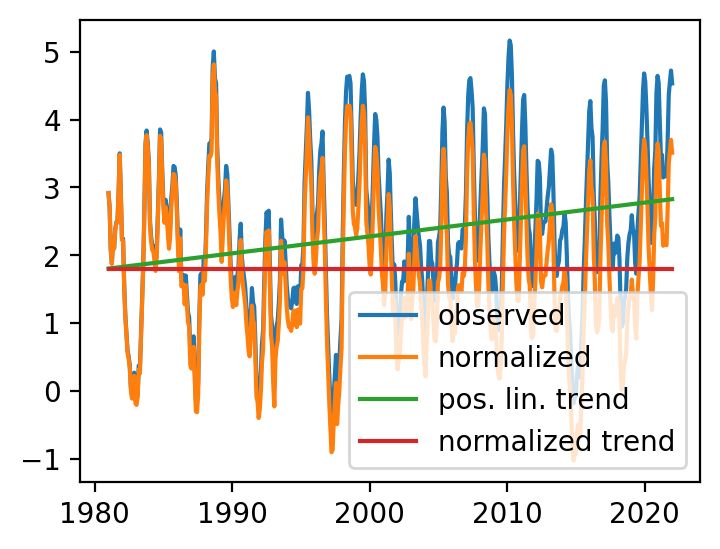

In [5]:
# start with gradient
# difference
grad = patch125 - nino34

# get trendline
xdates = np.linspace(firstyear, finalyear, len(grad))
xnum = np.arange(0,len(grad))

reg = linregress(xnum, grad)
m = reg.slope
b = reg.intercept
regpredict = m*xnum + b
# normalize by subtracting the linear regression
gradnorm = (grad - regpredict) + b

# check with the linear regression of detrended (zero) trend
reg2 = linregress(xnum, gradnorm)
m2 = reg2.slope
b2 = reg2.intercept
reg2predict = m2*xnum + b2

# check
fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(xdates, grad, label='observed')
ax.plot(xdates, gradnorm, label='normalized')
ax.plot(xdates, regpredict, label='pos. lin. trend')
ax.plot(xdates, reg2predict, label='normalized trend')
ax.legend()

# restack
gradstack = gradnorm.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))
filename = 'gradient_DeTrend_patch125-155_nino34.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

# Nino 3+Nino3.4 - patch(125-155) gradient

Actually patch(125-155) - Nino 3... (west minus east)

**Exported as `patch125-155_nino3-34`**

* Originally tested this part back when I was creating the SST gradient
* Decided not to use it 2/22/2023
* Suggested by Richard/Park from PhD advisory committee meeting 9/21/2023, so I revive my old code.

In [6]:
# create nino 3 sst index by month
boundslat = (sst.lat >= -5) & (sst.lat <= 5)
boundslon = (sst.lon >= (180+(180-170))) & (sst.lon <= (180+(180-90)))
nino334 = sst[:,boundslat, boundslon].mean(dim=['lat','lon']).values

# patch (125-155)
thisval = 125
boundslat = (sst.lat >= -5) & (sst.lat <= 5)
boundslon = (sst.lon >= thisval) & (sst.lon <= (thisval+30))
patch125 = sst[:,boundslat, boundslon].mean(dim=['lat','lon'], skipna=True).values

# difference
grad = patch125 - nino334

# restack
gradstack = grad.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))
filename = 'gradient_patch125-155_nino3-34.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

(42, 12)
exported gradient_patch125-155_nino3-34.txt


# Detrend Trend Nino3+Nino3.4 - patch(125-155) gradient

patch(125-155) minus Nino3+Nino3.4

Experimental, what if we were trending towards El Nino conditions instead of La Nina? What would the resulting burned area in western US look like? 

We take the timeseries and detrend it.

(42, 12)
exported gradient_DeTrend_patch125-155_nino3-34.txt


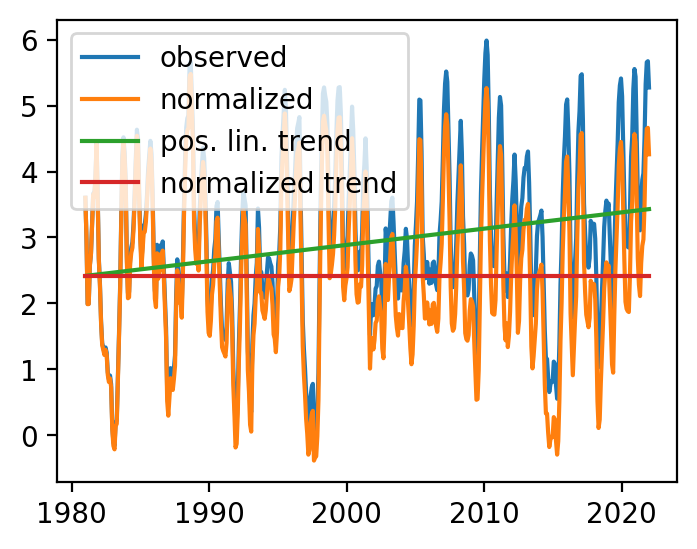

In [7]:
# start with gradient
# difference
grad = patch125 - nino334

# get trendline
xdates = np.linspace(firstyear, finalyear, len(grad))
xnum = np.arange(0,len(grad))

reg = linregress(xnum, grad)
m = reg.slope
b = reg.intercept
regpredict = m*xnum + b
# normalize by subtracting the linear regression
gradnorm = (grad - regpredict) + b

# check with the linear regression of detrended (zero) trend
reg2 = linregress(xnum, gradnorm)
m2 = reg2.slope
b2 = reg2.intercept
reg2predict = m2*xnum + b2

# check
fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(xdates, grad, label='observed')
ax.plot(xdates, gradnorm, label='normalized')
ax.plot(xdates, regpredict, label='pos. lin. trend')
ax.plot(xdates, reg2predict, label='normalized trend')
ax.legend()

# restack
gradstack = gradnorm.reshape(-1,12) # same format as nino 3
print(np.shape(gradstack))
filename = 'gradient_DeTrend_patch125-155_nino3-34.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

# Pacific Decadal Oscillation (PDO), NOAA

PDO from NOAA, last updated December 2024. Based on SST data NOAA ERSST v5 (to be consistent with the SST data in the figures).

The Pacific Decadal Oscillation (PDO) is often described as a long-lived El Niño-like pattern of Pacific climate variability (Zhang et al. 1997). As seen with the better-known El Niño/Southern Oscillation (ENSO), extremes in the PDO pattern are marked by widespread variations in the Pacific Basin and the North American climate. In parallel with the ENSO phenomenon, the extreme phases of the PDO have been classified as being either warm or cool, as defined by ocean temperature anomalies in the northeast and tropical Pacific Ocean. When SSTs are anomalously cool in the interior North Pacific and warm along the Pacific Coast, and when sea level pressures are below average over the North Pacific, the PDO has a positive value. When the climate anomaly patterns are reversed, with warm SST anomalies in the interior and cool SST anomalies along the North American coast, or above average sea level pressures over the North Pacific, the PDO has a negative value.

**Exported as `pdo_noaa`**

Link to website: https://psl.noaa.gov/pdo/ (under "Plots and Data"). Download the PSL Format.

In [8]:
# import data
filename = 'pdo_noaa'

# import PDO_NOAA for comparison
noaa_string = 'NOAA_SST//'
grad =  pd.read_csv(directory + noaa_string + 'pdo.timeseries.ersstv5.data.txt', 
                       header=None, sep="\s+", 
                       skiprows=[0,173,174,175,176,177,178]).set_index(0)

grad = grad.loc[firstyear:finalyear] # crop
# get dates associated with beginning of every 3 months
firstdate = str(firstyear)+'-01-15'
lastdate = str(finalyear+1)+'-01-15'
ninodate = pd.to_datetime(pd.date_range(start=firstdate, end=lastdate, freq='M'), unit='M')
ninotime = pd.DatetimeIndex(ninodate, freq='1M')
# flatten
clipdo_noaa = grad.to_numpy().flatten()
# create pd dataframe
grad = pd.DataFrame(data={'time': ninodate, 'anomaly': clipdo_noaa}).set_index('time')

# restack
gradstack = grad.anomaly.values.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
filename2 = 'gradient_'+filename+'.txt'
gradstack_df.to_csv(filename2, sep=',')
print('exported '+ filename2)

(42, 12)
exported gradient_pdo_noaa.txt


(42, 12)
exported gradient_DeTrend_pdo_noaa.txt


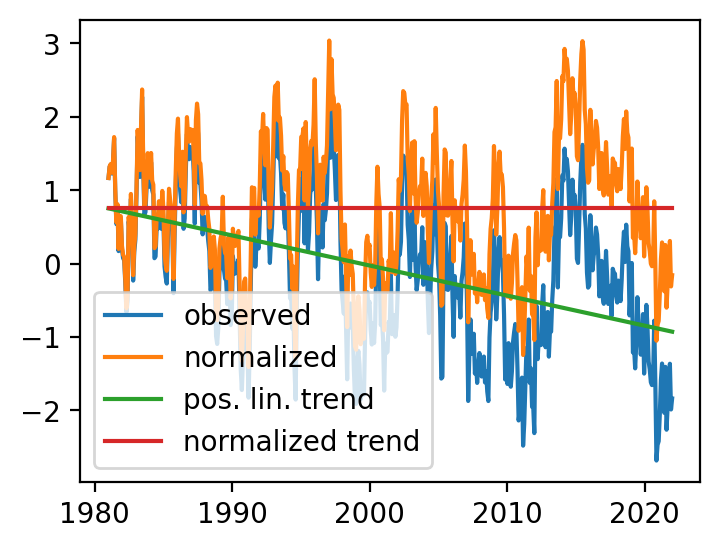

In [9]:
# detrend PDO_NOAA

# get trendline
xdates = np.linspace(firstyear, finalyear, len(sst))
xnum = np.arange(0,len(grad.anomaly))

reg = linregress(xnum, grad.anomaly.values)
m = reg.slope
b = reg.intercept
regpredict = m*xnum + b
# normalize by subtracting the linear regression
sstnorm = (grad.anomaly.values - regpredict) + b

# check with the linear regression of detrended (zero) trend
reg2 = linregress(xnum, sstnorm)
m2 = reg2.slope
b2 = reg2.intercept
reg2predict = m2*xnum + b2

# check
fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(xdates, grad.anomaly.values, label='observed')
ax.plot(xdates, sstnorm, label='normalized')
ax.plot(xdates, regpredict, label='pos. lin. trend')
ax.plot(xdates, reg2predict, label='normalized trend')
ax.legend()

# restack
gradstack = sstnorm.reshape(-1,12) # same format as nino 3
print(np.shape(gradstack))
filename2 = 'gradient_DeTrend_'+filename+'.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename2, sep=',')
print('exported '+ filename2)

# Southern Oscillation Index, NOAA

SOI from NOAA, last updated Feb 2025.

Calculation by NOAA Physical Sciences Laboratory, Source data from CRU
in PSL timeseries format.
https://psl.noaa.gov/gcos_wgsp/Timeseries/SOI/
CRU reference
https://crudata.uea.ac.uk/cru/data/soi/
file was updated sep 2024. All values were replaced from source.  Some had changed.
We are using the 2 decimal place version.
units=norm

The SOI is defined as the normalized pressure difference between Tahiti and Darwin. There are several slight variations in the SOI values calculated at various centres. Here we supply the SOI (from CRU) which is based on the method given by Ropelewski and Jones (1987).

Time Interval: Monthly
Time Coverage: 1866 to Aug 2021
Update Status: Periodically updated

**Exported as `SOI_NOAA`**

Link to website: https://psl.noaa.gov/data/timeseries/month/DS/SOI Where I downloaded.

In [10]:
# import data
filename = 'soi_noaa'

# import PDO_NOAA for comparison
noaa_string = 'NOAA_SST//'
grad =  pd.read_csv(directory + noaa_string + 'soi.long.data.txt', 
                       header=None, sep="\s+", 
                       skiprows=[0,161,162,163,164,165,166,167,168,169]).set_index(0)

grad = grad.loc[firstyear:finalyear] # crop
# get dates associated with beginning of every 3 months
firstdate = str(firstyear)+'-01-15'
lastdate = str(finalyear+1)+'-01-15'
ninodate = pd.to_datetime(pd.date_range(start=firstdate, end=lastdate, freq='M'), unit='M')
ninotime = pd.DatetimeIndex(ninodate, freq='1M')
# flatten
clipdo_noaa = grad.to_numpy().flatten()
# create pd dataframe
grad = pd.DataFrame(data={'time': ninodate, 'anomaly': clipdo_noaa}).set_index('time')

# restack
gradstack = grad.anomaly.values.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
filename2 = 'gradient_'+filename+'.txt'
gradstack_df.to_csv(filename2, sep=',')
print('exported '+ filename2)

(42, 12)
exported gradient_soi_noaa.txt


(42, 12)
exported gradient_DeTrend_soi_noaa.txt


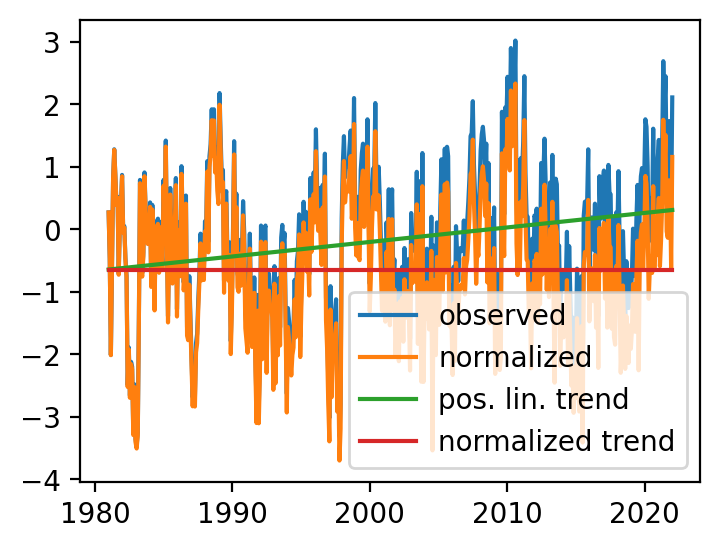

In [11]:
# detrend SOI_NOAA

# get trendline
xdates = np.linspace(firstyear, finalyear, len(sst))
xnum = np.arange(0,len(grad.anomaly))

reg = linregress(xnum, grad.anomaly.values)
m = reg.slope
b = reg.intercept
regpredict = m*xnum + b
# normalize by subtracting the linear regression
sstnorm = (grad.anomaly.values - regpredict) + b

# check with the linear regression of detrended (zero) trend
reg2 = linregress(xnum, sstnorm)
m2 = reg2.slope
b2 = reg2.intercept
reg2predict = m2*xnum + b2

# check
fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(xdates, grad.anomaly.values, label='observed')
ax.plot(xdates, sstnorm, label='normalized')
ax.plot(xdates, regpredict, label='pos. lin. trend')
ax.plot(xdates, reg2predict, label='normalized trend')
ax.legend()

# restack
gradstack = sstnorm.reshape(-1,12) # same format as nino 3
print(np.shape(gradstack))
filename2 = 'gradient_DeTrend_'+filename+'.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename2, sep=',')
print('exported '+ filename2)

# Multivariate ENSO Index (MEI), NOAA

MEI from NOAA, last updated Feb 2025.

Calculation by NOAA Physical Sciences Laboratory, Source data from NOAA, Japanese Meteorological Agency.
in PSL timeseries format.

The bi-monthly Multivariate El Niño/Southern Oscillation (ENSO) index (MEI.v2) is the time series of the leading combined Empirical Orthogonal Function (EOF) of five different variables (sea level pressure (SLP), sea surface temperature (SST), zonal and meridional components of the surface wind, and outgoing longwave radiation (OLR)) over the tropical Pacific basin (30°S-30°N and 100°E-70°W). The EOFs are calculated for 12 overlapping bi-monthly "seasons" (Dec-Jan, Jan-Feb, Feb-Mar,..., Nov-Dec) in order to take into account ENSO's seasonality, and reduce effects of higher frequency intraseasonal variability. During the typical height of ENSO during late Fall/early Winter, the canonical features of atmosphere and ocean anomalies are shown schematically below based on a composite of 11 historical El Niño and La Niña events. Key features of composite positive MEI events (warm, El Niño) include (1) anomalously warm SSTs across the east-central equatorial Pacific, (2) anomalously high SLP over Indonesia and the western tropical Pacific and low SLP over the eastern tropical Pacific, (3) reduction or reversal of tropical Pacific easterly winds (trade winds), (4) suppressed tropical convection (positive OLR) over Indonesia and Western Pacific and enhanced convection (negative OLR) over the central Pacific (Fig. 1a). Key features of composite negative MEI events (cold, La Niña, Fig. 1b) are of mostly opposite phase. For any single El Niño or La Niña situation, the atmospheric articulations may depart from this canonical view. 

A new version of the MEI (MEI.v2) has been created that uses 5 variables (sea level pressure (SLP), sea surface temperature (SST), surface zonal winds (U), surface meridional winds (V), and Outgoing Longwave Radiation (OLR)) to produce a time series of ENSO conditions from 1979 to present. The MEI.v2 expands upon the original MEI developed by Wolter and Timlin (1993) which was calculated using 6 variables as proxies for ENSO relevant atmosphere and ocean conditions.

In MEI.v2, the fields of SST, SLP, and surface zonal and meridional winds are obtained from the high-quality JRA-55 global reanalysis (Kobayashi et al. 2015). In contrast, the original MEI (Wolter and Timlin, 1993) used marine ship observations based on the International Comprehensive Ocean Atmosphere Data Set (ICOADS) and used near-surface air temperature as well as SST. The MEI.v2 also uses observations of OLR from NOAA Climate Data Record (CDR) of Monthly Outgoing Longwave Radiation (OLR), Version 2.7 (available from NOAA National Centers for Environmental Information (NCEI)); whereas the original MEI used ICOADS cloud cover fraction data. To produce the MEI.v2, all variables are interpolated to a common 2.5° latitude-longitude grid and standardized anomalies are computed with respect to the reference period of 1980-2018. As with the original version of the MEI (Wolter and Timlin, 2011), the MEI.v2 is calculated as the leading principal component (PC) time series of the Empirical Orthogonal Function (EOF) of the standardized anomalies of the above 5 combined variables over the tropical Pacific during 1980-2018. The EOF analysis is based on the covariance matrix and the analysis domain is the same as for the original MEI (30°S-30°N and 100°E-70°W, excluding the Atlantic Ocean and the land regions). A latitudinal weighting prior to the EOF analysis is applied.

The EOF analysis for MEI.v2 is conducted for 12 partially overlapping 2-month "seasons" (e.g., Wolter and Timlin, 1993). To obtain MEI.v2 values before 1980 and after 2018, standardized anomalies maps relative to the 1980-2018 reference period are projected onto the leading EOF pattern. Because the OLR record starts in January 1979, the DJ 1979 MEI.v2 value is based on January 1979 OLR data only. 

The JRA-55 dataset used for the MEI V2 has been discontinued by the Japanese Meteorological Agency as of January 2024. We have switched to using the JRA3Q reanalysis which yields very similar results. 
As the JRA55 has been discontinued we were able to calculate the MEI V2 index using the JRA3Q Reanalysys dataset. The spatial resolution is 1.5x1.5 and all other calulation details are the same. The correlation between the JRA55 version and the JRA3Q version is .998.

**Exported as `MEI_NOAA`**

Link to website: https://www.psl.noaa.gov/enso/mei/ Where I downloaded.

In [12]:
# import data
filename = 'mei_noaa'

# import PDO_NOAA for comparison
noaa_string = 'NOAA_SST//'
grad =  pd.read_csv(directory + noaa_string + 'meiv2.data.txt', 
                       header=None, sep="\s+", 
                       skiprows=[0,48,49,50,51]).set_index(0)

grad = grad.loc[firstyear:finalyear] # crop
# get dates associated with beginning of every 3 months
firstdate = str(firstyear)+'-01-15'
lastdate = str(finalyear+1)+'-01-15'
ninodate = pd.to_datetime(pd.date_range(start=firstdate, end=lastdate, freq='M'), unit='M')
ninotime = pd.DatetimeIndex(ninodate, freq='1M')
# flatten
clipdo_noaa = grad.to_numpy().flatten()
# create pd dataframe
grad = pd.DataFrame(data={'time': ninodate, 'anomaly': clipdo_noaa}).set_index('time')

# restack
gradstack = grad.anomaly.values.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
filename2 = 'gradient_'+filename+'.txt'
gradstack_df.to_csv(filename2, sep=',')
print('exported '+ filename2)

(42, 12)
exported gradient_mei_noaa.txt


(42, 12)
exported gradient_DeTrend_mei_noaa.txt


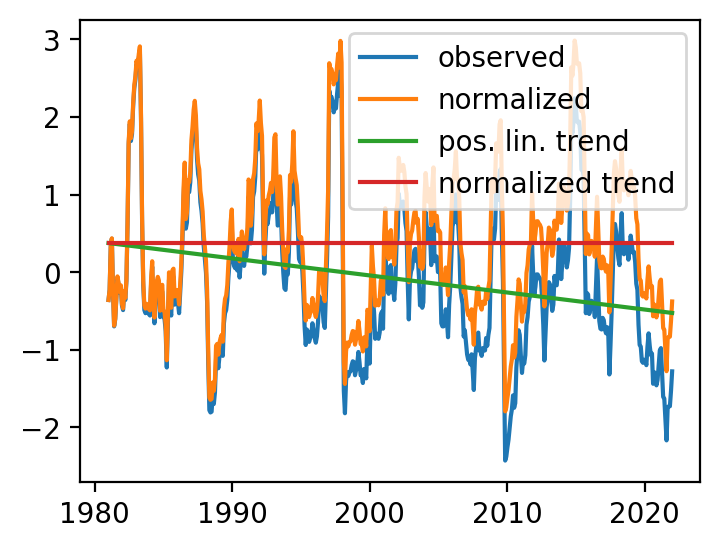

In [13]:
# detrend SOI_NOAA

# get trendline
xdates = np.linspace(firstyear, finalyear, len(sst))
xnum = np.arange(0,len(grad.anomaly))

reg = linregress(xnum, grad.anomaly.values)
m = reg.slope
b = reg.intercept
regpredict = m*xnum + b
# normalize by subtracting the linear regression
sstnorm = (grad.anomaly.values - regpredict) + b

# check with the linear regression of detrended (zero) trend
reg2 = linregress(xnum, sstnorm)
m2 = reg2.slope
b2 = reg2.intercept
reg2predict = m2*xnum + b2

# check
fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(xdates, grad.anomaly.values, label='observed')
ax.plot(xdates, sstnorm, label='normalized')
ax.plot(xdates, regpredict, label='pos. lin. trend')
ax.plot(xdates, reg2predict, label='normalized trend')
ax.legend()

# restack
gradstack = sstnorm.reshape(-1,12) # same format as nino 3
print(np.shape(gradstack))
filename2 = 'gradient_DeTrend_'+filename+'.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename2, sep=',')
print('exported '+ filename2)

# Sensitivity Analysis (2025 R2R)

I'm going to keep the labels for these simple, with a,b,c,d.

* a. shift up 2 degrees
* b. shift down 2 degrees
* c. shift left 2 degrees
* d. shift right 2 degrees

## (a) Nino 3+Nino3.4 - patch(125-155) gradient

Actually patch(125-155) - Nino 3... (west minus east)

**Exported as `patch125-155_nino3-34a`**

In [14]:
# create nino 3 sst index by month
boundslat = (sst.lat >= -3) & (sst.lat <= 7)
boundslon = (sst.lon >= (180+(180-170))) & (sst.lon <= (180+(180-90)))
nino334 = sst[:,boundslat, boundslon].mean(dim=['lat','lon']).values

# patch (125-155)
thisval = 125
boundslat = (sst.lat >= -4) & (sst.lat <= 6)
boundslon = (sst.lon >= thisval) & (sst.lon <= (thisval+30))
patch125 = sst[:,boundslat, boundslon].mean(dim=['lat','lon'], skipna=True).values

# difference
grad = patch125 - nino334

# restack
gradstack = grad.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))
filename = 'gradient_patch125-155_nino3-34a.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

(42, 12)
exported gradient_patch125-155_nino3-34a.txt


## (a) Detrend Trend Nino3+Nino3.4 - patch(125-155) gradient

patch(125-155) minus Nino3+Nino3.4

Experimental, what if we were trending towards El Nino conditions instead of La Nina? What would the resulting burned area in western US look like? 

We take the timeseries and detrend it.

(42, 12)
exported gradient_DeTrend_patch125-155_nino3-34a.txt


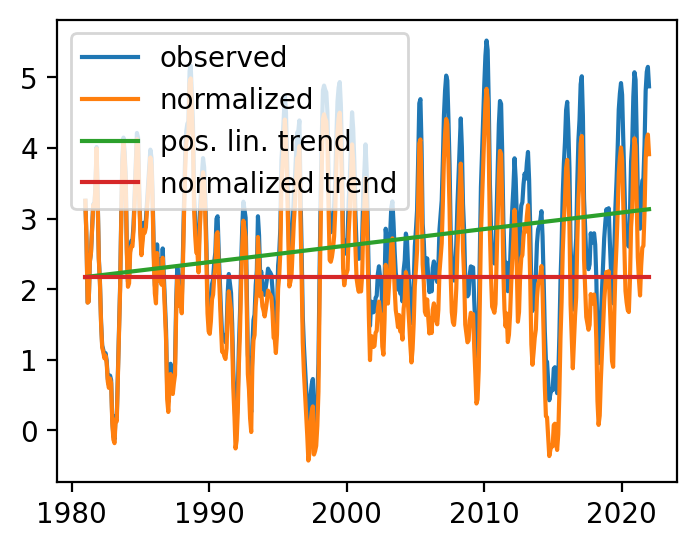

In [15]:
# start with gradient
# difference
grad = patch125 - nino334

# get trendline
xdates = np.linspace(firstyear, finalyear, len(grad))
xnum = np.arange(0,len(grad))

reg = linregress(xnum, grad)
m = reg.slope
b = reg.intercept
regpredict = m*xnum + b
# normalize by subtracting the linear regression
gradnorm = (grad - regpredict) + b

# check with the linear regression of detrended (zero) trend
reg2 = linregress(xnum, gradnorm)
m2 = reg2.slope
b2 = reg2.intercept
reg2predict = m2*xnum + b2

# check
fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(xdates, grad, label='observed')
ax.plot(xdates, gradnorm, label='normalized')
ax.plot(xdates, regpredict, label='pos. lin. trend')
ax.plot(xdates, reg2predict, label='normalized trend')
ax.legend()

# restack
gradstack = gradnorm.reshape(-1,12) # same format as nino 3
print(np.shape(gradstack))
filename = 'gradient_DeTrend_patch125-155_nino3-34a.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

## (b) Nino 3+Nino3.4 - patch(125-155) gradient

Actually patch(125-155) - Nino 3... (west minus east)

**Exported as `patch125-155_nino3-34b`**

In [16]:
# create nino 3 sst index by month
boundslat = (sst.lat >= -7) & (sst.lat <= 3)
boundslon = (sst.lon >= (180+(180-170))) & (sst.lon <= (180+(180-90)))
nino334 = sst[:,boundslat, boundslon].mean(dim=['lat','lon']).values

# patch (125-155)
thisval = 125
boundslat = (sst.lat >= -7) & (sst.lat <= 3)
boundslon = (sst.lon >= thisval) & (sst.lon <= (thisval+30))
patch125 = sst[:,boundslat, boundslon].mean(dim=['lat','lon'], skipna=True).values

# difference
grad = patch125 - nino334

# restack
gradstack = grad.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))
filename = 'gradient_patch125-155_nino3-34b.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

(42, 12)
exported gradient_patch125-155_nino3-34b.txt


## (b) Detrend Trend Nino3+Nino3.4 - patch(125-155) gradient

patch(125-155) minus Nino3+Nino3.4

Experimental, what if we were trending towards El Nino conditions instead of La Nina? What would the resulting burned area in western US look like? 

We take the timeseries and detrend it.

(42, 12)
exported gradient_DeTrend_patch125-155_nino3-34b.txt


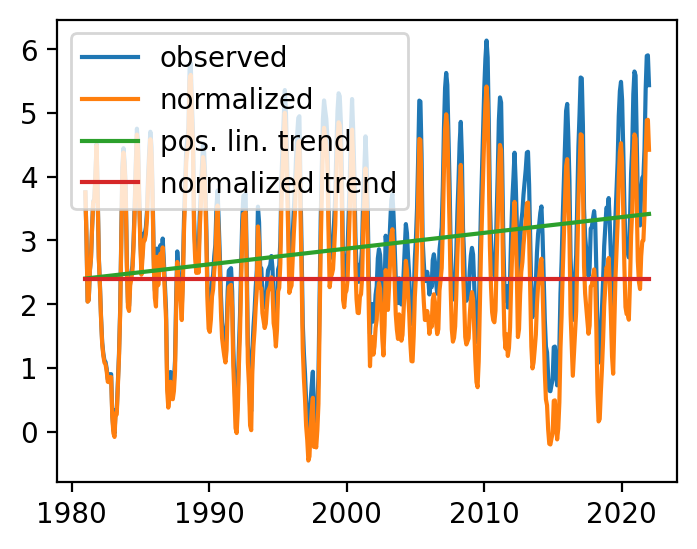

In [17]:
# start with gradient
# difference
grad = patch125 - nino334

# get trendline
xdates = np.linspace(firstyear, finalyear, len(grad))
xnum = np.arange(0,len(grad))

reg = linregress(xnum, grad)
m = reg.slope
b = reg.intercept
regpredict = m*xnum + b
# normalize by subtracting the linear regression
gradnorm = (grad - regpredict) + b

# check with the linear regression of detrended (zero) trend
reg2 = linregress(xnum, gradnorm)
m2 = reg2.slope
b2 = reg2.intercept
reg2predict = m2*xnum + b2

# check
fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(xdates, grad, label='observed')
ax.plot(xdates, gradnorm, label='normalized')
ax.plot(xdates, regpredict, label='pos. lin. trend')
ax.plot(xdates, reg2predict, label='normalized trend')
ax.legend()

# restack
gradstack = gradnorm.reshape(-1,12) # same format as nino 3
print(np.shape(gradstack))
filename = 'gradient_DeTrend_patch125-155_nino3-34b.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

## (c) Nino 3+Nino3.4 - patch(125-155) gradient

Actually patch(125-155) - Nino 3... (west minus east)

**Exported as `patch125-155_nino3-34c`**

In [18]:
# create nino 3 sst index by month
boundslat = (sst.lat >= -5) & (sst.lat <= 5)
boundslon = (sst.lon >= (180+(180-170)+2)) & (sst.lon <= (180+(180-90)+2))
nino334 = sst[:,boundslat, boundslon].mean(dim=['lat','lon']).values

# patch (125-155)
thisval = 125+2
boundslat = (sst.lat >= -5) & (sst.lat <= 5)
boundslon = (sst.lon >= thisval) & (sst.lon <= (thisval+30))
patch125 = sst[:,boundslat, boundslon].mean(dim=['lat','lon'], skipna=True).values

# difference
grad = patch125 - nino334

# restack
gradstack = grad.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))
filename = 'gradient_patch125-155_nino3-34c.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

(42, 12)
exported gradient_patch125-155_nino3-34c.txt


## (c) Detrend Trend Nino3+Nino3.4 - patch(125-155) gradient

patch(125-155) minus Nino3+Nino3.4

Experimental, what if we were trending towards El Nino conditions instead of La Nina? What would the resulting burned area in western US look like? 

We take the timeseries and detrend it.

(42, 12)
exported gradient_DeTrend_patch125-155_nino3-34c.txt


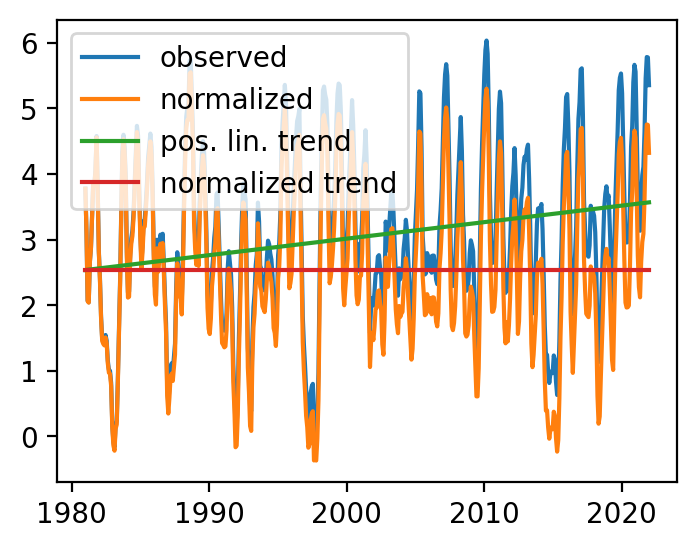

In [19]:
# start with gradient
# difference
grad = patch125 - nino334

# get trendline
xdates = np.linspace(firstyear, finalyear, len(grad))
xnum = np.arange(0,len(grad))

reg = linregress(xnum, grad)
m = reg.slope
b = reg.intercept
regpredict = m*xnum + b
# normalize by subtracting the linear regression
gradnorm = (grad - regpredict) + b

# check with the linear regression of detrended (zero) trend
reg2 = linregress(xnum, gradnorm)
m2 = reg2.slope
b2 = reg2.intercept
reg2predict = m2*xnum + b2

# check
fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(xdates, grad, label='observed')
ax.plot(xdates, gradnorm, label='normalized')
ax.plot(xdates, regpredict, label='pos. lin. trend')
ax.plot(xdates, reg2predict, label='normalized trend')
ax.legend()

# restack
gradstack = gradnorm.reshape(-1,12) # same format as nino 3
print(np.shape(gradstack))
filename = 'gradient_DeTrend_patch125-155_nino3-34c.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

## (d) Nino 3+Nino3.4 - patch(125-155) gradient

Actually patch(125-155) - Nino 3+3.4 (west minus east)

**Exported as `patch125-155_nino3-34d`**

In [20]:
# create nino 3 sst index by month
boundslat = (sst.lat >= -5) & (sst.lat <= 5)
boundslon = (sst.lon >= (180+(180-170)-2)) & (sst.lon <= (180+(180-90)-2))
nino334 = sst[:,boundslat, boundslon].mean(dim=['lat','lon']).values

# patch (125-155)
thisval = 125-2
boundslat = (sst.lat >= -5) & (sst.lat <= 5)
boundslon = (sst.lon >= thisval) & (sst.lon <= (thisval+30))
patch125 = sst[:,boundslat, boundslon].mean(dim=['lat','lon'], skipna=True).values

# difference
grad = patch125 - nino334

# restack
gradstack = grad.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))
filename = 'gradient_patch125-155_nino3-34d.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

(42, 12)
exported gradient_patch125-155_nino3-34d.txt


## (d) Detrend Trend Nino3+Nino3.4 - patch(125-155) gradient

patch(125-155) minus Nino3+Nino3.4

Experimental, what if we were trending towards El Nino conditions instead of La Nina? What would the resulting burned area in western US look like? 

We take the timeseries and detrend it.

(42, 12)
exported gradient_DeTrend_patch125-155_nino3-34d.txt


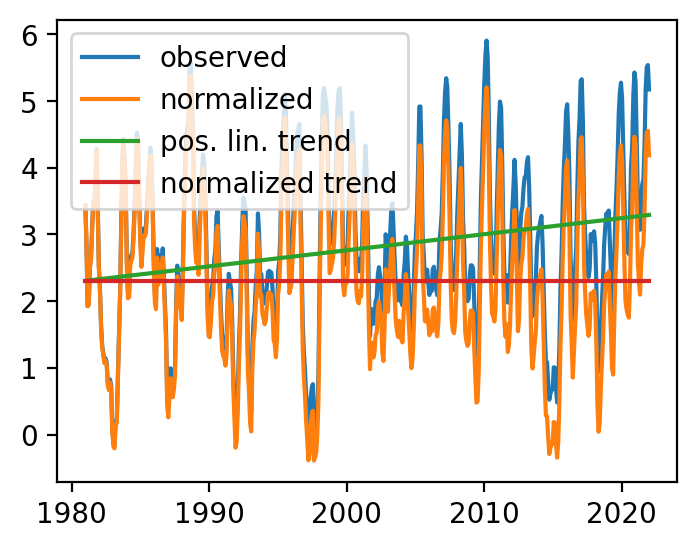

In [21]:
# start with gradient
# difference
grad = patch125 - nino334

# get trendline
xdates = np.linspace(firstyear, finalyear, len(grad))
xnum = np.arange(0,len(grad))

reg = linregress(xnum, grad)
m = reg.slope
b = reg.intercept
regpredict = m*xnum + b
# normalize by subtracting the linear regression
gradnorm = (grad - regpredict) + b

# check with the linear regression of detrended (zero) trend
reg2 = linregress(xnum, gradnorm)
m2 = reg2.slope
b2 = reg2.intercept
reg2predict = m2*xnum + b2

# check
fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(xdates, grad, label='observed')
ax.plot(xdates, gradnorm, label='normalized')
ax.plot(xdates, regpredict, label='pos. lin. trend')
ax.plot(xdates, reg2predict, label='normalized trend')
ax.legend()

# restack
gradstack = gradnorm.reshape(-1,12) # same format as nino 3
print(np.shape(gradstack))
filename = 'gradient_DeTrend_patch125-155_nino3-34d.txt'
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

# patch(125-155) - Nino 3+3.4 gradient (JMA COBE SST v2)
patch(125-155) - Nino3.4 

West - East (to get a positive value)

**Exported as `patch125-155_nino34_COBEv2`**

Data from https://psl.noaa.gov/data/gridded/data.cobe2.html

In [4]:
# use JMA SST data now
# import sst data
#sst = xr.open_dataset(directory + 'NOAA_SST\\sst.mnmean.nc', engine='netcdf4')
sst = xr.open_dataset(directory + 'NOAA_SST//sst.mon.mean_COBEv2.nc', engine='netcdf4')
sst = sst.sst.loc[firsttime:finaltime] 

In [5]:
filename = 'gradient_patch125-155_nino3-34_COBEv2.txt' # to name the gradient

boundslat = (sst.lat >= -5) & (sst.lat <= 5)
boundslon = (sst.lon >= (180+(180-170))) & (sst.lon <= (180+(180-90)))
nino334 = sst[:,boundslat, boundslon].mean(dim=['lat','lon']).values

# patch (125-155)
thisval = 125
boundslon = (sst.lon >= thisval) & (sst.lon <= (thisval+30))
patch125 = sst[:,boundslat, boundslon].mean(dim=['lat','lon'], skipna=True).values

# difference
grad = patch125 - nino334 # west minus east

# restack
gradstack = grad.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

(42, 12)
exported gradient_patch125-155_nino3-34_COBEv2.txt


# Detrend Trend Nino3+3.4 - patch(125-155) gradient (JMA COBE V2)

Experimental, what if we were trending towards El Nino conditions instead of La Nina? What would the resulting burned area in western US look like? 

We take the timeseries and detrend it.

(42, 12)
exported gradient_DeTrend_patch125-155_nino3-34_COBEv2.txt


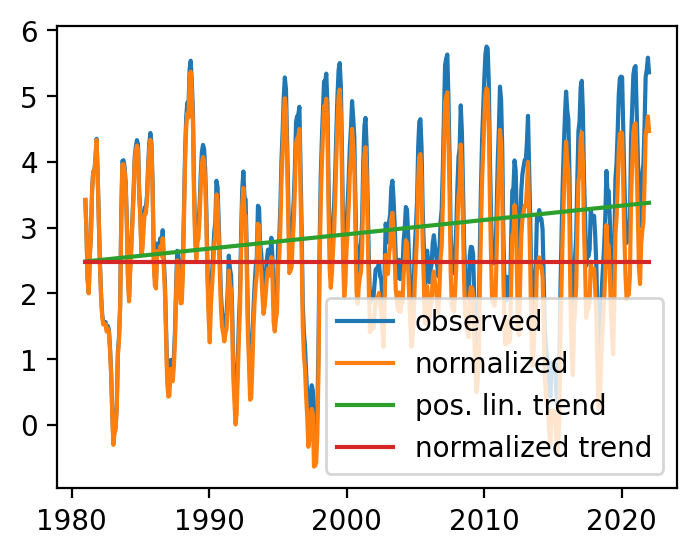

In [6]:
filename = 'gradient_DeTrend_patch125-155_nino3-34_COBEv2.txt'
# start with gradient
# difference
grad = patch125 - nino334

# get trendline
xdates = np.linspace(firstyear, finalyear, len(grad))
xnum = np.arange(0,len(grad))

reg = linregress(xnum, grad)
m = reg.slope
b = reg.intercept
regpredict = m*xnum + b
# normalize by subtracting the linear regression
gradnorm = (grad - regpredict) + b

# check with the linear regression of detrended (zero) trend
reg2 = linregress(xnum, gradnorm)
m2 = reg2.slope
b2 = reg2.intercept
reg2predict = m2*xnum + b2

# check
fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(xdates, grad, label='observed')
ax.plot(xdates, gradnorm, label='normalized')
ax.plot(xdates, regpredict, label='pos. lin. trend')
ax.plot(xdates, reg2predict, label='normalized trend')
ax.legend()

# restack
gradstack = gradnorm.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))

gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

# patch(125-155) - Nino 3+3.4 gradient (HadISST1)
patch(125-155) - Nino3.4 

West - East (to get a positive value)

**Exported as `patch125-155_nino34_HadISST1`**

Data from https://www.metoffice.gov.uk/hadobs/hadisst/data/download.html

In [4]:
# use Met Office Hadley Centre data now
# import sst data
#sst = xr.open_dataset(directory + 'NOAA_SST\\sst.mnmean.nc', engine='netcdf4')
sst = xr.open_dataset(directory + 'NOAA_SST//HadISST_sst.nc', engine='netcdf4')
sst = sst.sst.loc[firsttime:finaltime] 

In [26]:
filename = 'gradient_patch125-155_nino3-34_HadISST1.txt' # to name the gradient

boundslat = (sst.latitude >= -5) & (sst.latitude <= 5)
# note: had to adjust the longitude because it is not 0 to 360,
# rather it is now -180 to 180
boundslon = (sst.longitude >= (-170)) & (sst.longitude <= (-90))
#boundslon = (sst.lon >= (180+(180-170))) & (sst.lon <= (180+(180-90)))
nino334 = sst[:,boundslat, boundslon].mean(dim=['latitude','longitude']).values

# patch (125-155)
thisval = 125
boundslon = (sst.longitude >= thisval) & (sst.longitude <= (thisval+30))
patch125 = sst[:,boundslat, boundslon].mean(dim=['latitude','longitude'], skipna=True).values

# difference
grad = patch125 - nino334 # west minus east

# restack
gradstack = grad.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))
gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)

(42, 12)
exported gradient_patch125-155_nino3-34_HadISST1.txt


# Detrend Trend Nino3+3.4 - patch(125-155) gradient (Met Office HadISST1)

Experimental, what if we were trending towards El Nino conditions instead of La Nina? What would the resulting burned area in western US look like? 

We take the timeseries and detrend it.

(42, 12)
exported gradient_DeTrend_patch125-155_nino3-34_HadISST1.txt


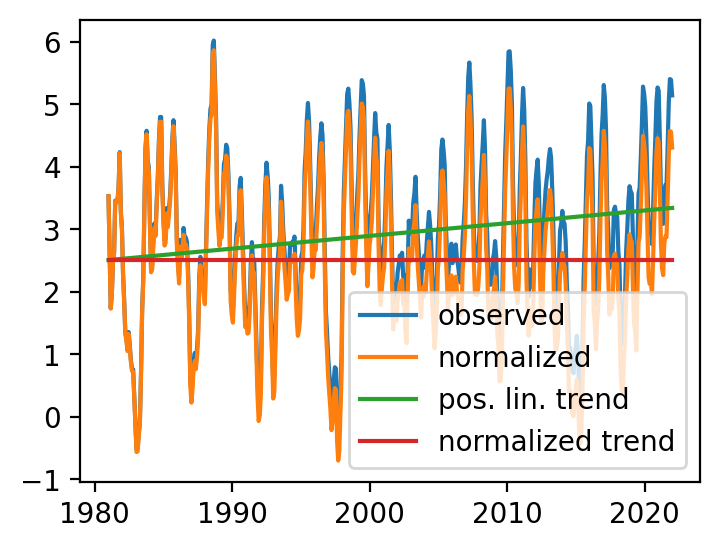

In [28]:
filename = 'gradient_DeTrend_patch125-155_nino3-34_HadISST1.txt'
# start with gradient
# difference
grad = patch125 - nino334

# get trendline
xdates = np.linspace(firstyear, finalyear, len(grad))
xnum = np.arange(0,len(grad))

reg = linregress(xnum, grad)
m = reg.slope
b = reg.intercept
regpredict = m*xnum + b
# normalize by subtracting the linear regression
gradnorm = (grad - regpredict) + b

# check with the linear regression of detrended (zero) trend
reg2 = linregress(xnum, gradnorm)
m2 = reg2.slope
b2 = reg2.intercept
reg2predict = m2*xnum + b2

# check
fig, ax = plt.subplots(figsize=(4,3), dpi=200)
ax.plot(xdates, grad, label='observed')
ax.plot(xdates, gradnorm, label='normalized')
ax.plot(xdates, regpredict, label='pos. lin. trend')
ax.plot(xdates, reg2predict, label='normalized trend')
ax.legend()

# restack
gradstack = gradnorm.reshape(-1,12) # same format as nino 3.4
print(np.shape(gradstack))

gradstack_df = pd.DataFrame(gradstack, index=np.arange(firstyear, finalyear+1), 
                            columns=np.arange(1,12+1))
gradstack_df.to_csv(filename, sep=',')
print('exported '+ filename)